# Parity-Net Colab Runner
This notebook clones the GitHub repo, trains the mean-field-style residual network from `MOTIVATION.md`, saves checkpoints to Google Drive, and runs PCA rank-reduction analysis.
Before running, set `GITHUB_REPO_URL` to the URL of your pushed repo.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
GITHUB_REPO_URL = "https://github.com/labofdoubt/feature-learning-parity-task.git"
REPO_DIR = "/content/feature-learning-parity-task"

!rm -rf "$REPO_DIR"
!git clone "$GITHUB_REPO_URL"
%cd "$REPO_DIR"
!pip install -e .


Cloning into 'feature-learning-parity-task'...
remote: Enumerating objects: 56, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 56 (delta 24), reused 50 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (56/56), 322.93 KiB | 35.88 MiB/s, done.
Resolving deltas: 100% (24/24), done.
/content/feature-learning-parity-task
Obtaining file:///content/feature-learning-parity-task
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for parity-net (pyproject.toml) ... done
  Created wheel for parity-net: filename=parity_net-0.1.0-0.editable-py3-none-any.whl size=3070 sha256=ad3c6e94ce78cc7526ec2290ebe8246e54622e823e12229c3b3b822aaff96812
  Stored in directory: /tmp/pip-ephem-wheel-cache-kv228mpk/wheels/a2/05/6b/5da726f55833c1e289bd27eaf6964cb7ead0a

In [4]:
DRIVE_RUN_DIR = "/content/drive/MyDrive/ml_projects_new/parity_runs/example_run_11"

## Create Configs
`barrier_c` is in the training config because it enters as a loss regularizer. If left as `None`, the training code uses `7 / N`.



In [ ]:
from pathlib import Path
import yaml

N = 512

config = {
    "model": {
        "input_dim": 32,
        "relevant_dim": 16,
        "N": N,
        "L": 4,
        "activation": "relu",
        "use_readout_barrier": False,
        "embedding_weight_variance": 1.0/32,
        "hidden_weight_variance": 1.0/N,
        "readout_weight_variance": 1.0/N,
        "use_post_activation_linear": True,
        "bias": False,
    },
    "training": {
        "num_steps": 20_000,
        "test_samples": 100_000,
        "batch_size": 256,
        "seed": 0,
        "device": "cuda",
        "dtype": "float32",
        "log_every": 1_000,
        "checkpoint_every": 1_000,
        "output_dir": DRIVE_RUN_DIR,
        "barrier_c": None,
        "barrier_lambda": 10.0,
        "optimizer": {
            "name": "adamw",
            "lr": 1e-4,
            "weight_decay": 0.0,
            "momentum": 0.0,
            "betas": [0.9, 0.999],
        },
    },
}
config_path = Path(DRIVE_RUN_DIR) / "config.yaml"
config_path.parent.mkdir(parents=True, exist_ok=True)
with config_path.open("w") as f:
    yaml.safe_dump(config, f, sort_keys=False)
config_path




PosixPath('/content/drive/MyDrive/ml_projects_new/parity_runs/example_run_11/config.yaml')

## Train

Training samples a fresh random batch at every optimizer step. `num_steps` is the number of weight updates.
This runs the repo command and saves intermediate checkpoints to Google Drive.



In [7]:
!parity-train --config "$config_path"

{'step': 1000, 'elapsed_seconds': 3.6537743569999748, 'train_mse': 0.4246633052825928, 'barrier': 0.0, 'loss': 0.4246633052825928, 'test_mse': 0.42433473467826843, 'test_mse_d2': 0.08432061970233917, 'test_mse_d4': 0.5994715690612793, 'test_mse_d8': 1.0944082736968994, 'test_mse_d16': 1.1037530899047852}
{'step': 2000, 'elapsed_seconds': 6.986767927000017, 'train_mse': 0.24051888287067413, 'barrier': 0.0, 'loss': 0.24051888287067413, 'test_mse': 0.24048246443271637, 'test_mse_d2': 0.03610233962535858, 'test_mse_d4': 0.04880572110414505, 'test_mse_d8': 1.0423105955123901, 'test_mse_d16': 1.0385738611221313}
{'step': 3000, 'elapsed_seconds': 10.328370867999979, 'train_mse': 0.21707263588905334, 'barrier': 0.0, 'loss': 0.21707263588905334, 'test_mse': 0.2133069634437561, 'test_mse_d2': 0.019263623282313347, 'test_mse_d4': 0.02419719658792019, 'test_mse_d8': 0.9596381187438965, 'test_mse_d16': 1.0294302701950073}
{'step': 4000, 'elapsed_seconds': 13.645295970999996, 'train_mse': 0.13643442

## Load Checkpoint and Inspect Weight Variance



In [8]:
import torch
import pandas as pd
from parity_net.checkpoint import load_checkpoint
from parity_net.train import resolve_device
checkpoint_path = Path(DRIVE_RUN_DIR) / "checkpoints" / "step_00020000.pt"
device = resolve_device(config["training"]["device"])
model, payload, _ = load_checkpoint(checkpoint_path, device)
weight_variances = model.weight_variances()
pd.DataFrame([
    {"layer": layer, "variance": variance}
    for layer, variance in weight_variances.items()
])

,layer,variance
0,embedding.weight,0.031249
1,blocks.0.linear.weight,0.001953
2,blocks.1.linear.weight,0.001882
3,blocks.2.linear.weight,0.001923
4,blocks.3.linear.weight,0.001962
5,readout.weight,0.001588


## Inspect Predictions on Test Samples

Run inference on a fresh held-out batch and compare model outputs with the true parity targets for a few samples.


In [9]:
from parity_net.data import make_dataset
from parity_net.train import resolve_dtype

num_inspect_samples = 5
inspect_batch_size = 32

dtype = resolve_dtype(config["training"]["dtype"])
inspect_data = make_dataset(
    inspect_batch_size,
    config["model"]["input_dim"],
    config["model"]["relevant_dim"],
    device,
    dtype,
)

model.eval()
with torch.no_grad():
    inspect_pred = model(inspect_data.x)

input_columns = [f"x{i}" for i in range(config["model"]["input_dim"])]
output_columns = [
    *[f"d2_{i}" for i in range(8)],
    *[f"d4_{i}" for i in range(4)],
    *[f"d8_{i}" for i in range(2)],
    "d16_0",
]

for sample_idx in range(num_inspect_samples):
    input_sequence = pd.DataFrame(
        [inspect_data.x[sample_idx].detach().cpu().numpy().astype(int)],
        columns=input_columns,
    )
    comparison = pd.DataFrame(
        {
            "target": inspect_data.y[sample_idx].detach().cpu().numpy(),
            "prediction": inspect_pred[sample_idx].detach().cpu().numpy(),
        },
        index=output_columns,
    )
    print(f"Sample {sample_idx}: input sequence")
    display(input_sequence)
    print(f"Sample {sample_idx}: targets vs predictions")
    display(comparison)


Sample 0: input sequence


,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31
0,1,1,1,1,-1,-1,-1,1,1,-1,...,1,1,1,-1,-1,-1,-1,-1,-1,1


Sample 0: targets vs predictions


,target,prediction
d2_0,1.0,0.993244
d2_1,1.0,0.980989
d2_2,1.0,1.023052
d2_3,-1.0,-1.002557
d2_4,-1.0,-0.968256
d2_5,1.0,0.988168
d2_6,-1.0,-1.021361
d2_7,1.0,1.011147
d4_0,1.0,0.991026
d4_1,-1.0,-1.008173


Sample 1: input sequence


...

,target,prediction
d2_0,-1.0,-1.039232
d2_1,1.0,0.998783
d2_2,-1.0,-1.003272
d2_3,-1.0,-0.994714
d2_4,1.0,1.019599
d2_5,1.0,1.017726
d2_6,-1.0,-1.022877
d2_7,-1.0,-0.964125
d4_0,-1.0,-1.000416
d4_1,1.0,1.015819


Sample 4: input sequence


,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31
0,1,-1,1,1,1,-1,-1,1,1,1,...,1,1,1,1,1,1,-1,-1,1,1


Sample 4: targets vs predictions


,target,prediction
d2_0,-1.0,-1.023945
d2_1,1.0,0.977189
d2_2,-1.0,-0.996774
d2_3,-1.0,-0.996180
d2_4,1.0,0.994667
d2_5,1.0,1.026103
d2_6,-1.0,-1.016295
d2_7,-1.0,-0.971209
d4_0,-1.0,-1.015191
d4_1,1.0,0.990643


## Inspect Layerwise Activation Variance

Run inference on a fresh input batch and measure, for each sample, the activation variance across the hidden dimension after the embedding and after each residual block.


In [10]:
activation_batch_size = 256

activation_data = make_dataset(
    activation_batch_size,
    config["model"]["input_dim"],
    config["model"]["relevant_dim"],
    device,
    dtype,
)

model.eval()
with torch.no_grad():
    _, activations = model(activation_data.x, return_activations=True)

rows = []
for layer_idx, h in enumerate(activations):
    layer_name = "embedding" if layer_idx == 0 else f"block_{layer_idx}"
    sample_variances = h.detach().float().var(dim=1, unbiased=False)
    rows.append(
        {
            "layer_idx": layer_idx,
            "layer": layer_name,
            "mean_sample_variance": sample_variances.mean().item(),
            "std_sample_variance": sample_variances.std(unbiased=False).item(),
            "min_sample_variance": sample_variances.min().item(),
            "max_sample_variance": sample_variances.max().item(),
        }
    )

activation_variance_df = pd.DataFrame(rows)
display(activation_variance_df)


,layer_idx,layer,mean_sample_variance,std_sample_variance,min_sample_variance,max_sample_variance
0,0,embedding,0.998024,0.002757,0.983230,1.000000
1,1,block_1,1.355961,0.089209,1.108472,1.630963
2,2,block_2,1.688187,0.101958,1.450892,1.980345
3,3,block_3,3.563673,0.274029,2.908842,4.302295
4,4,block_4,8.467812,0.688322,6.901785,10.377445


## PCA Rank-Reduction Analysis
Set `INTERVENTION_LAYER_IDX`, `KEEP_PCS_MIN`, `KEEP_PCS_MAX`, and `KEEP_PCS_STEP` below. Layer index `0` is the embedded residual stream before the first residual block; later indices are after residual blocks / before the corresponding next block.


Baseline MSE


,mse_all,mse_d2,mse_d4,mse_d8,mse_d16
0,0.000562,0.000422,0.000345,0.001037,0.001596


PCA rank thresholds


,layer_idx,rank_90,rank_99,num_dimensions
0,0,29,32,512
1,1,31,54,512
2,2,36,59,512
3,3,39,63,512
4,4,40,64,512


PCA intervention MSE sweep


,intervention_layer,keep_pcs,mse_all,mse_d2,mse_d4,mse_d8,mse_d16
0,4,0,1.000153,1.000180,1.000082,1.000105,1.000316
1,4,1,0.935537,0.999877,0.764031,0.989174,0.999570
2,4,2,0.884243,0.999569,0.574143,0.985589,0.999348
3,4,3,0.879208,0.997037,0.560586,0.985090,0.999297
4,4,4,0.873371,0.995928,0.541236,0.984446,0.999302
...,...,...,...,...,...,...,...
66,4,66,0.005935,0.004546,0.003035,0.010081,0.020353
67,4,67,0.005111,0.003849,0.002893,0.009835,0.014628
68,4,68,0.004444,0.003704,0.002074,0.007223,0.014285
69,4,69,0.003996,0.003470,0.001749,0.007094,0.011002


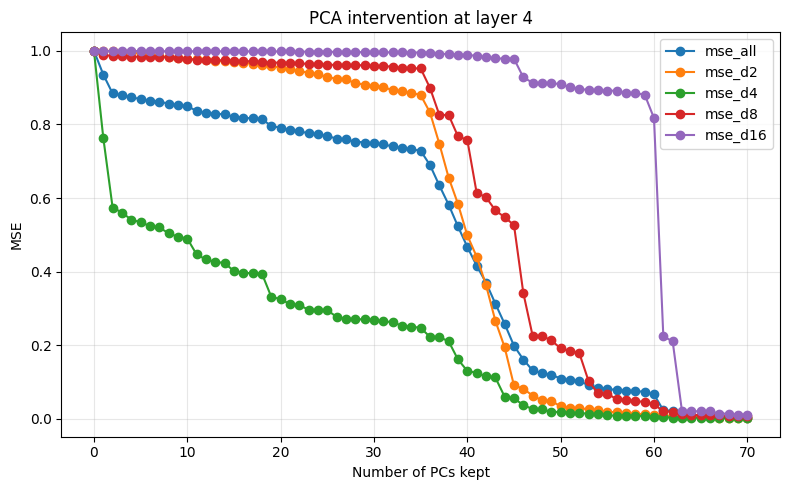

In [21]:
import matplotlib.pyplot as plt
from parity_net.data import make_dataset
from parity_net.analysis import (
    collect_layer_activations,
    make_pca_intervention,
    pca_from_activations,
    per_degree_mse,
    predict_in_batches,
    rank_for_threshold,
)

INTERVENTION_LAYER_IDX = 4
KEEP_PCS_MIN = 0
KEEP_PCS_MAX = 70
KEEP_PCS_STEP = 1
PCA_SAMPLES = config["training"]["test_samples"]
ANALYSIS_DIR = Path(DRIVE_RUN_DIR) / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

analysis_config = payload["config"]
analysis_training = analysis_config["training"]
analysis_model_config = analysis_config["model"]
batch_size = analysis_training["batch_size"]

torch.manual_seed(analysis_training["seed"] + 10_000)
heldout = make_dataset(
    PCA_SAMPLES,
    analysis_model_config["input_dim"],
    analysis_model_config["relevant_dim"],
    device,
    dtype,
)

model.eval()
with torch.no_grad():
    baseline_pred = predict_in_batches(model, heldout.x, batch_size)
baseline_metrics = per_degree_mse(baseline_pred, heldout.y)
pd.DataFrame([baseline_metrics]).to_csv(ANALYSIS_DIR / "baseline_mse.csv", index=False)
print("Baseline MSE")
display(pd.DataFrame([baseline_metrics]))

activations = collect_layer_activations(model, heldout.x, batch_size)
pcas = [pca_from_activations(layer_acts) for layer_acts in activations]

rank_rows = []
for layer_idx, pca in enumerate(pcas):
    cumulative = pca["cumulative_explained_variance"]
    rank_rows.append(
        {
            "layer_idx": layer_idx,
            "rank_90": rank_for_threshold(cumulative, 0.90),
            "rank_99": rank_for_threshold(cumulative, 0.99),
            "num_dimensions": cumulative.numel(),
        }
    )
rank_df = pd.DataFrame(rank_rows)
rank_df.to_csv(ANALYSIS_DIR / "pca_rank_thresholds.csv", index=False)
print("PCA rank thresholds")
display(rank_df)

if INTERVENTION_LAYER_IDX < 0 or INTERVENTION_LAYER_IDX >= len(pcas):
    raise ValueError(f"INTERVENTION_LAYER_IDX must be in [0, {len(pcas) - 1}]")
if KEEP_PCS_STEP <= 0:
    raise ValueError("KEEP_PCS_STEP must be positive")
if KEEP_PCS_MIN < 0:
    raise ValueError("KEEP_PCS_MIN must be non-negative")
if KEEP_PCS_MAX < KEEP_PCS_MIN:
    raise ValueError("KEEP_PCS_MAX must be at least KEEP_PCS_MIN")

max_available_pcs = pcas[INTERVENTION_LAYER_IDX]["components"].shape[0]
keep_pcs_max_effective = min(KEEP_PCS_MAX, max_available_pcs)
if keep_pcs_max_effective < KEEP_PCS_MAX:
    print(f"Capping KEEP_PCS_MAX at {keep_pcs_max_effective}; only that many PCs are available.")
if KEEP_PCS_MIN > keep_pcs_max_effective:
    raise ValueError(
        f"KEEP_PCS_MIN={KEEP_PCS_MIN} exceeds available PCs={keep_pcs_max_effective} "
        f"at layer {INTERVENTION_LAYER_IDX}"
    )

keep_pcs_values = list(range(KEEP_PCS_MIN, keep_pcs_max_effective + 1, KEEP_PCS_STEP))
if keep_pcs_values[-1] != keep_pcs_max_effective:
    keep_pcs_values.append(keep_pcs_max_effective)

sweep_rows = []
for keep_pcs in keep_pcs_values:
    intervention = make_pca_intervention(pcas[INTERVENTION_LAYER_IDX], keep_pcs)
    with torch.no_grad():
        pred_intervened = predict_in_batches(
            model,
            heldout.x,
            batch_size,
            intervention=(INTERVENTION_LAYER_IDX, intervention),
        )
    sweep_rows.append(
        {
            "intervention_layer": INTERVENTION_LAYER_IDX,
            "keep_pcs": keep_pcs,
            **per_degree_mse(pred_intervened, heldout.y),
        }
    )

pca_sweep_df = pd.DataFrame(sweep_rows)
pca_sweep_df.to_csv(ANALYSIS_DIR / "pca_intervention_mse_sweep.csv", index=False)
print("PCA intervention MSE sweep")
display(pca_sweep_df)

mse_columns = ["mse_all", "mse_d2", "mse_d4", "mse_d8", "mse_d16"]
ax = pca_sweep_df.plot(
    x="keep_pcs",
    y=mse_columns,
    marker="o",
    figsize=(8, 5),
)
ax.set_xlabel("Number of PCs kept")
ax.set_ylabel("MSE")
ax.set_title(f"PCA intervention at layer {INTERVENTION_LAYER_IDX}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "pca_intervention_mse_sweep.png", dpi=150)
plt.show()


## Results
The first table reports how many dimensions recover 90% and 99% of variance at each layer. The second reports MSE after the PCA intervention, including degree 2, 4, 8, and 16 parity groups.



In [12]:
rank_df = pd.read_csv(Path(ANALYSIS_DIR) / "pca_rank_thresholds.csv")
intervention_df = pd.read_csv(Path(ANALYSIS_DIR) / "pca_intervention_mse.csv")
baseline_df = pd.read_csv(Path(ANALYSIS_DIR) / "baseline_mse.csv")
print("PCA rank thresholds")
display(rank_df)
print("Baseline MSE")
display(baseline_df)
print("PCA intervention MSE")
display(intervention_df[["intervention_layer", "keep_pcs", "mse_d2", "mse_d4", "mse_d8", "mse_d16", "mse_all"]])



PCA rank thresholds


,layer_idx,rank_90,rank_99,num_dimensions
0,0,29,32,512
1,1,31,54,512
2,2,36,59,512
3,3,39,63,512
4,4,40,64,512


Baseline MSE


,mse_all,mse_d2,mse_d4,mse_d8,mse_d16
0,0.000562,0.000422,0.000345,0.001037,0.001596


PCA intervention MSE


,intervention_layer,keep_pcs,mse_d2,mse_d4,mse_d8,mse_d16,mse_all
0,2,50,0.022841,0.012645,0.061798,0.048411,0.027021
